# NLP Course 1 - Week 3 Alternative Assignment

## Semantic Word Relationships with Vector Space Models

---

## Assignment Overview

**Your Mission**: Explore the geometric structure of word meanings using **vector space models**. You'll work with pre-trained word embeddings to discover semantic relationships, implement similarity metrics, and visualize high-dimensional word vectors using PCA.

**The Big Shift from Previous Weeks**:

- **Week 1**: Text → Numbers (feature extraction + logistic regression)
- **Week 2**: Text → Probabilities (frequency counting + Naive Bayes)
- **Week 3**: Words → Geometric Vectors (embeddings + vector operations)

**What Makes This Week Special**:

- You're NOT training a model - you're using pre-trained embeddings
- Focus is on **geometric relationships** between words
- Discover hidden patterns through **vector arithmetic**
- Visualize **300-dimensional space** in 2D

**Expected Time**: 5-7 hours
**Difficulty**: Intermediate (heavy on linear algebra and visualization)

## Learning Objectives

By completing this assignment, you will:

1. **Understand word embeddings** - Pre-trained vector representations of words
2. **Implement similarity metrics** - Cosine similarity and Euclidean distance
3. **Perform word analogies** - Solve "king - man + woman = ?" type problems
4. **Apply PCA** - Reduce 300D vectors to 2D for visualization
5. **Discover semantic clusters** - See how similar words group together
6. **Build intuition** - Understand why vector spaces work for NLP
7. **Compare metrics** - When to use cosine vs Euclidean distance
8. **Analyze limitations** - Understand what embeddings can't capture

## Core Concept: What are Word Embeddings?

### The Fundamental Idea

**Word embeddings** are dense vector representations of words where:

- Each word = a point in high-dimensional space (typically 50-300 dimensions)
- Similar words = nearby points in this space
- Semantic relationships = geometric directions

**Example**:

```python
# Each word is a 300-dimensional vector
king = [0.23, -0.45, 0.67, ..., 0.12]    # 300 numbers
queen = [0.28, -0.42, 0.71, ..., 0.18]   # 300 numbers
man = [0.11, -0.52, 0.34, ..., 0.09]     # 300 numbers
woman = [0.15, -0.49, 0.39, ..., 0.14]   # 300 numbers

# Relationships are captured geometrically:
king - man ≈ queen - woman  # Gender relationship!
```

### Why This Matters

**The magic**: Words that appear in similar contexts get similar vectors

- "happy" and "joyful" → appear near each other
- "Paris" and "France" → geographic relationship preserved
- "doctor" and "nurse" → professional relationship captured

## Setup and imports

In [32]:
%pip install gensim


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import random
from typing import List, Dict, Tuple, Set
from sklearn.model_selection import train_test_split
import string  

import nltk
# download the stopwords from NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import pickle
from gensim.models import KeyedVectors
import time

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

[nltk_data] Downloading package stopwords to /home/bidut/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Dataset and Setup

### Word Embeddings

You'll use **pre-trained word embeddings** instead of movie reviews!

**Source**: Google News Word2Vec (trained on 100 billion words)
**Dimensions**: 300 per word
**Vocabulary**: ~3 million words

**For this assignment, we'll use a subset**:

- Countries and capitals (Athens, Greece, Bangkok, Thailand, etc.)
- Common adjectives (happy, sad, joyful)
- Related concepts (oil, gas, petroleum)
- Geographic terms (city, town, village, country)

### Getting the Data

**Option 1: Use provided pickle file** (recommended)

```python
import pickle
word_embeddings = pickle.load(open("word_embeddings_subset.p", "rb"))
```

**Option 2: Download full Google News embeddings**

- Download from: https://code.google.com/archive/p/word2vec/
- File: GoogleNews-vectors-negative300.bin.gz (~3.6 GB)
- Load using gensim: `KeyedVectors.load_word2vec_format()`

**Option 3: Use alternative embeddings**

- GloVe embeddings (Stanford NLP)
- FastText (Facebook Research)
- Your choice - experiment!

### Dataset Structure

```python
# word_embeddings is a dictionary
{
    'king': array([0.23, -0.45, ..., 0.12]),     # 300-dim vector
    'queen': array([0.28, -0.42, ..., 0.18]),    # 300-dim vector
    'Greece': array([0.15, 0.23, ..., -0.09]),   # 300-dim vector
    'Athens': array([0.18, 0.29, ..., -0.05]),   # 300-dim vector
    # ... ~243 words total
}
```

In [2]:
print("Loading word embeddings from Google News Word2Vec model")
print("This may take a few minutes")

model_path = '../data/GoogleNews-vectors-negative300.bin'
full_model = KeyedVectors.load_word2vec_format(model_path, binary=True)

print(f"Full model loaded. Total vocabulary: {len(full_model)} words\n")

words_to_extract = [
    'Athens', 'Greece', 'Bangkok', 'Thailand', 'Beijing', 'China',
    'Berlin', 'Germany', 'Bern', 'Switzerland', 'Cairo', 'Egypt',
    'Canberra', 'Australia', 'Hanoi', 'Vietnam', 'Havana', 'Cuba',
    'Helsinki', 'Finland', 'Islamabad', 'Pakistan', 'Kabul', 'Afghanistan',
    'London', 'England', 'Madrid', 'Spain', 'Moscow', 'Russia',
    'Oslo', 'Norway', 'Ottawa', 'Canada', 'Paris', 'France',
    'Rome', 'Italy', 'Stockholm', 'Sweden', 'Tokyo', 'Japan',
    'Washington', 'USA', 'king', 'queen', 'man', 'woman',
    'prince', 'princess', 'father', 'mother', 'brother', 'sister',
    'uncle', 'aunt', 'happy', 'sad', 'joyful', 'miserable',
    'excited', 'bored', 'good', 'bad', 'excellent', 'terrible',
    'oil', 'gas', 'petroleum', 'city', 'town', 'village',
    'country', 'nation', 'state', 'doctor', 'nurse', 'engineer',
    'teacher', 'programmer', 'secretary', 'CEO', 'assistant',
    'he', 'she', 'his', 'her', 'him', 'male', 'female', 'fuel','energy',
    'angry', 'pleased', 'continent', 'monarch',
    'boy', 'better', 'big', 'bigger', 'small', 'fast', 'faster', 'slow',
    'french', 'chinese', 'Indian', 'german', 'India',
    'apple', 'iphone', 'microsoft', 'google',
    'search', 'facebook', 'nike', 'shoes', 'rolex',
    'spanish', 'italian', 'english', 'russian', 'japanese', 'swedish',
    'norwegian', 'pakistani', 'australian', 'vietnamese', 'finnish',
    'egyptian', 'swiss', 'cuban', 'afghan', 'canadian', 'american',
    'windows', 'office', 'bing', 'android', 'gmail', 'youtube',
    'adidas', 'watch', 'luxury', 'brand'
]

word_embeddings = {}

print("Creating subset of embeddings...")
for word in words_to_extract:
    if word in full_model:
        word_embeddings[word] = full_model[word]
    else:
        print(f"Warning: '{word}' not found in vocabulary")

print(f"\nSubset created successfully!")
print(f"Total words in subset: {len(word_embeddings)}")
print(f"Embedding dimension: {len(next(iter(word_embeddings.values())))}")

pickle.dump(word_embeddings, open("word_embeddings_subset.p", "wb"))
print("\nSaved subset to 'word_embeddings_subset.p'")

del full_model
print("Full model removed from memory to save space")

Loading word embeddings from Google News Word2Vec model
This may take a few minutes
Full model loaded. Total vocabulary: 3000000 words

Creating subset of embeddings...

Subset created successfully!
Total words in subset: 145
Embedding dimension: 300

Saved subset to 'word_embeddings_subset.p'
Full model removed from memory to save space


In [3]:
print(f"Number of words: {len(word_embeddings)}")
print(f"\nExample words: {list(word_embeddings.keys())[:10]}")
print(f"\nVector for 'king': shape = {word_embeddings['king'].shape}")
print(f"First 5 dimensions: {word_embeddings['king'][:5]}")

Number of words: 145

Example words: ['Athens', 'Greece', 'Bangkok', 'Thailand', 'Beijing', 'China', 'Berlin', 'Germany', 'Bern', 'Switzerland']

Vector for 'king': shape = (300,)
First 5 dimensions: [ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477]


## Part 1: Similarity Metrics

### Milestone 1.1: Implement Cosine Similarity

**What to implement**: Create `cosine_similarity(vec_a, vec_b)` function

**Mathematical Foundation**:

$$\cos(\theta) = \frac{\vec{A} \cdot \vec{B}}{||\vec{A}|| \times ||\vec{B}||} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \times \sqrt{\sum_{i=1}^{n} B_i^2}}$$

**Interpretation**:

- **cos(θ) = 1**: Vectors point in same direction (identical meaning)
- **cos(θ) = 0**: Vectors are perpendicular (unrelated)
- **cos(θ) = -1**: Vectors point in opposite directions (antonyms)
- **cos(θ) ∈ [0.5, 1.0]**: Similar words

**⚠️ GOTCHA #1**: Division by zero!

- If either vector has zero magnitude, cosine is undefined
- For word embeddings, this shouldn't happen (all words have non-zero vectors)
- But add a check: `if norm_a == 0 or norm_b == 0: return 0.0`


**Example calculation (by hand)**:

```python
# Simple 3D example
A = np.array([1, 2, 3])
B = np.array([2, 4, 6])  # B = 2A (same direction)

# Dot product: 1×2 + 2×4 + 3×6 = 2 + 8 + 18 = 28
# ||A|| = √(1² + 2² + 3²) = √14 ≈ 3.742
# ||B|| = √(4 + 16 + 36) = √56 ≈ 7.483
# cos(θ) = 28 / (3.742 × 7.483) = 28 / 28 = 1.0

# Perfect similarity - vectors are parallel!
```

**💡 Hints**:

- Use `np.dot(a, b)` for dot product
- Use `np.linalg.norm(a)` for vector magnitude
- Or compute manually: `np.sqrt(np.sum(a**2))`

**🎓 Concepts from Week 3 Material**:

- Cosine similarity intuition (Section 4)
- Mathematical foundation (Section 5)
- Geometric interpretation of angles

In [4]:
def cosine_similarity(vec_a, vec_b):
    """
    Calculate cosine similarity between two vectors

    Args:
        vec_a: numpy array of shape (n,)
        vec_b: numpy array of shape (n,)

    Returns:
        similarity: float in range [-1, 1]

    Formula:
        cos(θ) = (A · B) / (||A|| × ||B||)
    """
    # print(f"vec_a = {vec_a}")
    # print(f"vec_b = {vec_b}")

    numerator = np.dot(vec_a, vec_b)
    # print("numerator : ",numerator)

    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)

    # print("norm_a : ",norm_a)
    # print("norm_b : ",norm_b)

    if norm_a==0 or norm_b==0:
        return 0.0

    denominator = norm_a * norm_b
    # print("denominator : ",denominator)

    res = numerator / denominator
    # print("res : ",res)

    return res


**Test your function:**

In [5]:
# Test 1: Identical vectors
A = np.array([1, 2, 3])
assert abs(cosine_similarity(A, A) - 1.0) < 1e-6

# Test 2: Orthogonal vectors
A = np.array([1, 0, 0])
B = np.array([0, 1, 0])
assert abs(cosine_similarity(A, B) - 0.0) < 1e-6

# Test 3: Opposite vectors
A = np.array([1, 2, 3])
B = np.array([-1, -2, -3])
assert abs(cosine_similarity(A, B) - (-1.0)) < 1e-6

# Test 4: Real word vectors
king = word_embeddings['king']
queen = word_embeddings['queen']
similarity = cosine_similarity(king, queen)
print(f"king ↔ queen similarity: {similarity:.3f}")
assert 0.5 < similarity < 1.0  # Should be fairly similar

king ↔ queen similarity: 0.651


### Milestone 1.2: Implement Euclidean Distance

**What to implement**: Create `euclidean_distance(vec_a, vec_b)` function

**Mathematical Foundation**:

$$d(\vec{A}, \vec{B}) = ||\vec{A} - \vec{B}|| = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2}$$

**Interpretation**:

- **d = 0**: Vectors are identical
- **Small d**: Vectors are close (similar words)
- **Large d**: Vectors are far apart (different words)
- **No upper bound**: Distance can be arbitrarily large

**⚠️ GOTCHA #2**: Euclidean vs Cosine - which to use?

- **Euclidean**: Sensitive to vector magnitude AND direction
- **Cosine**: Only sensitive to direction (magnitude-invariant)
- **For word embeddings**: Cosine is usually better!
- **Why**: "happy" (rare) and "joyful" (common) may have different magnitudes

**Example calculation (by hand)**:

```python
# Simple 2D example
A = np.array([3, 4])
B = np.array([6, 8])

# Distance = √((3-6)² + (4-8)²)
#          = √(9 + 16)
#          = √25
#          = 5.0
```

**💡 Hints**:

- Method 1: `np.linalg.norm(vec_a - vec_b)`
- Method 2: `np.sqrt(np.sum((vec_a - vec_b)**2))`
- Both work - choose based on readability

**🎓 Concepts from Week 3 Material**:

- Euclidean distance (Section 3)
- When to use distance vs similarity
- Geometric interpretation

In [6]:
def euclidean_distance(vec_a, vec_b):
    """
    Calculate Euclidean distance between two vectors

    Args:
        vec_a: numpy array of shape (n,)
        vec_b: numpy array of shape (n,)

    Returns:
        distance: float >= 0

    Formula:
        d(A, B) = ||A - B|| = √(Σ(Ai - Bi)²)
    """
    
    res = np.linalg.norm(vec_a - vec_b)

    return res

In [7]:
# Test 1: Same point
A = np.array([1, 2, 3])
assert euclidean_distance(A, A) == 0.0

# Test 2: Known distance
A = np.array([0, 0])
B = np.array([3, 4])
assert abs(euclidean_distance(A, B) - 5.0) < 1e-6  # 3-4-5 triangle

# Test 3: Symmetry
assert euclidean_distance(A, B) == euclidean_distance(B, A)

# Test 4: Real word vectors
king = word_embeddings['king']
queen = word_embeddings['queen']
man = word_embeddings['man']
woman = word_embeddings['woman']

d_king_queen = euclidean_distance(king, queen)
d_king_man = euclidean_distance(king, man)

print("Test Passed")
print(f"Distance: king ↔ queen = {d_king_queen:.3f}")
print(f"Distance: king ↔ man = {d_king_man:.3f}")

Test Passed
Distance: king ↔ queen = 2.480
Distance: king ↔ man = 3.269


### Milestone 1.3: Compare Metrics on Word Pairs

#### Test with interesting pairs

```python
word_pairs = [
    ('king', 'queen'),
    ('king', 'man'),
    ('happy', 'sad'),
    ('oil', 'petroleum'),
    ('Greece', 'Athens'),
    ('France', 'Paris'),
]

comparison = compare_similarity_metrics(word_pairs, word_embeddings)
print(comparison)
```

**⚠️ GOTCHA #3**: Rankings may differ!

- A pair with high cosine similarity may not have low Euclidean distance
- This happens when vectors have different magnitudes
- Example: "king" (common word) vs "monarch" (rare word)

**Questions to answer:**

1. Which pairs have highest cosine similarity?
2. Which pairs have lowest Euclidean distance?
3. Are the rankings the same?
4. When do the metrics disagree most?

In [8]:
def compare_similarity_metrics(word_pairs, word_embeddings):
    """
    Compare cosine similarity and Euclidean distance for word pairs
    """
    results = []

    for word1, word2 in word_pairs:
        vec1 = word_embeddings[word1]
        vec2 = word_embeddings[word2]

        cos_sim = cosine_similarity(vec1, vec2)
        euc_dist = euclidean_distance(vec1, vec2)

        # Normalize Euclidean for comparison (scale to [0, 1])
        norm1 = np.linalg.norm(vec1)
        norm2 = np.linalg.norm(vec2)

        results.append({
            'word1': word1,
            'word2': word2,
            'cosine_similarity': cos_sim,
            'euclidean_distance': euc_dist,
            'norm_word1': norm1,
            'norm_word2': norm2
        })

    return pd.DataFrame(results)

In [9]:
word_pairs = [
    ('king', 'queen'),
    ('king', 'man'),
    ('happy', 'sad'),
    ('oil', 'petroleum'),
    ('Greece', 'Athens'),
    ('France', 'Paris'),
]

comparison = compare_similarity_metrics(word_pairs, word_embeddings)
print(comparison)

    word1      word2  cosine_similarity  euclidean_distance  norm_word1  \
0    king      queen           0.651096            2.479692    2.902259   
1    king        man           0.229427            3.268789    2.902259   
2   happy        sad           0.535461            2.614465    2.466733   
3     oil  petroleum           0.765507            2.121974    2.901808   
4  Greece     Athens           0.588816            2.865941    3.278593   
5  France      Paris           0.633491            2.366143    2.716706   

   norm_word2  
0    3.028304  
1    2.310617  
2    2.900484  
3    3.229666  
4    3.021923  
5    2.807293  


## Part 2: Word Analogies

### Milestone 2.1: Understand the Analogy Problem

The Classic Example: "King is to Queen as Man is to ?"

**Vector arithmetic approach**:

```
Relationship = King - Man
Answer = Woman + Relationship
       = Woman + (King - Man)
       = Woman + King - Man
```

**Mathematical formula**:
$$\vec{d} \approx \vec{c} + (\vec{b} - \vec{a})$$

For "a : b :: c : d", we want to find **d** such that:
$$\vec{b} - \vec{a} \approx \vec{d} - \vec{c}$$

**Why this works**: Relationships are captured as **directions** in vector space!

**⚠️ GOTCHA #4**: This is APPROXIMATE, not exact!

- Real embeddings: King - Man + Woman ≈ Queen (not exactly)
- You'll get Queen as the closest match, but not perfect overlap
- This is expected and normal!

In [10]:
def analogy_vector(word_a, word_b, word_c, embeddings):
    """
    Compute the target vector for the analogy: 
    'a is to b as c is to ?'  →  d ≈ c + (b - a)
    
    Args:
        word_a (str): first word (e.g., "man")
        word_b (str): second word (e.g., "king")
        word_c (str): third word (e.g., "woman")
        embeddings (dict[str, np.ndarray]): word embedding dictionary

    Returns:
        np.ndarray: the resulting analogy vector for the target word
    """
    vec_a = embeddings[word_a]
    vec_b = embeddings[word_b]
    vec_c = embeddings[word_c]

    # analogy relationship - d ≈ c + (b - a)
    target_vec = vec_c + (vec_b - vec_a)

    return target_vec

In [11]:
def find_closest_word(target_vec, embeddings, exclude=None):
    """
    Find the word in the embedding dictionary that is most similar 
    (by cosine similarity) to a given target vector.

    Args:
        target_vec (np.ndarray): 
            The target vector we want to find the closest matching word for.
            Typically computed from an analogy like c + (b - a).

        embeddings (dict[str, np.ndarray]): 
            Dictionary mapping words to their embedding vectors.

        exclude (list[str], optional): 
            Words to ignore during the search (e.g., ['man', 'king', 'woman'] 
            when predicting 'queen'). Defaults to None.

    Returns:
        tuple[str, float]:
            - best_word: The most similar word found.
            - best_score: The cosine similarity score for that word (range: -1 to 1).
    """
    best_word = None
    best_score = -1 #cos similarity ranges from -1 to 1

    for word, vec in embeddings.items():
        if word in exclude:
            continue

        cos_sim = cosine_similarity(target_vec, vec)

        if cos_sim > best_score:
            best_score = cos_sim
            best_word = word

    return best_word, best_score
    


In [12]:
# Example usage: "King is to Man as Queen is to ?"
word_a = "man"
word_b = "king"
word_c = "woman"

target_vec = analogy_vector(word_a, word_b, word_c, word_embeddings)
predicted_word, similarity = find_closest_word(target_vec, word_embeddings, exclude=[word_a, word_b, word_c])

print(f"'{word_a}' is to '{word_b}' as '{word_c}' is to '{predicted_word}' (similarity = {similarity:.4f})")

'man' is to 'king' as 'woman' is to 'queen' (similarity = 0.7301)


In [13]:
analogies = [
    # Gender relationships
    ("man", "king", "woman"),        # → queen
    ("prince", "man", "princess"),   # → woman
    ("father", "mother", "brother"), # → sister
    ("uncle", "aunt", "father"),     # → mother
    ("he", "his", "she"),            # → her

    # Royalty & hierarchy
    ("king", "queen", "prince"),     # → princess

    # Country–Capital relationships
    ("Paris", "France", "Rome"),     # → Italy
    ("Athens", "Greece", "Bangkok"), # → Thailand
    ("Berlin", "Germany", "Tokyo"),  # → Japan
    ("Cairo", "Egypt", "Ottawa"),    # → Canada
    ("Helsinki", "Finland", "Oslo"), # → Norway
    ("Beijing", "China", "Moscow"),  # → Russia

    # Emotion/Quality contrasts
    ("happy", "sad", "good"),        # → bad
    ("excellent", "good", "terrible"), # → bad or miserable
    ("excited", "bored", "joyful"),  # → miserable

    # Profession parallels
    ("doctor", "nurse", "engineer"), # → programmer
    ("CEO", "assistant", "king"),    # → queen
]


for a, b, c in analogies:
    target_vec = analogy_vector(a, b, c, word_embeddings)
    predicted_word, sim = find_closest_word(target_vec, word_embeddings, exclude=[a, b, c])
    print(f"{a:10} : {b:10} :: {c:10} : {predicted_word:10}  (sim={sim:.3f})")


man        : king       :: woman      : queen       (sim=0.730)
prince     : man        :: princess   : woman       (sim=0.666)
father     : mother     :: brother    : sister      (sim=0.843)
uncle      : aunt       :: father     : mother      (sim=0.907)
he         : his        :: she        : her         (sim=0.962)
king       : queen      :: prince     : princess    (sim=0.724)
Paris      : France     :: Rome       : Italy       (sim=0.712)
Athens     : Greece     :: Bangkok    : Thailand    (sim=0.735)
Berlin     : Germany    :: Tokyo      : Japan       (sim=0.801)
Cairo      : Egypt      :: Ottawa     : Canada      (sim=0.659)
Helsinki   : Finland    :: Oslo       : Norway      (sim=0.727)
Beijing    : China      :: Moscow     : Russia      (sim=0.850)
happy      : sad        :: good       : terrible    (sim=0.636)
excellent  : good       :: terrible   : bad         (sim=0.723)
excited    : bored      :: joyful     : miserable   (sim=0.317)
doctor     : nurse      :: engineer   : 

### Milestone 2.2: Implement Word Analogy Solver

**What to implement**: Create `complete_analogy(word_a, word_b, word_c, embeddings, k=5)` function

**Algorithm:**

```
1. Get vectors: vec_a, vec_b, vec_c
2. Calculate relationship: relationship = vec_b - vec_a
3. Predict target: target = vec_c + relationship
4. For each word in vocabulary:
    - Calculate similarity between word vector and target
    - Skip word_a, word_b, word_c themselves
5. Sort by similarity (descending)
6. Return top k candidates
```

**⚠️ GOTCHA #5**: Don't include input words in results!

- Your answer shouldn't be "king is to queen as man is to king"
- Filter out word_a, word_b, word_c from candidates
- This is a common mistake!

**💡 Hints**:

- Use your `cosine_similarity` function for each candidate
- Store results as list of (word, similarity) tuples
- Use Python's `sorted()` with key parameter
- `sorted(candidates, key=lambda x: x[1], reverse=True)`

**🎓 Concepts from Week 3 Material**:

- Manipulating words in vector spaces (Section 6)
- Vector arithmetic for semantic relationships
- Analogy solving with embeddings


In [14]:
def complete_analogy(word_a, word_b, word_c, embeddings, k=5):
    """
    Solve analogy: word_a is to word_b as word_c is to ?

    Args:
        word_a (str): first word (e.g., "king")
        word_b (str): second word (e.g., "queen")
        word_c (str): third word (e.g., "man")
        embeddings (dict[str, np.ndarray]): dictionary of word embeddings
        k (int, optional): number of top candidates to return. Default = 5

    Returns:
        list[tuple[str, float]]: list of (word, similarity) pairs
    """

    # Safety check: edge case : ensure all words are in the vocabulary
    for w in [word_a, word_b, word_c]:
        if w not in embeddings:
            raise ValueError(f"Word '{w}' not found in embeddings.")


    vec_a = embeddings[word_a]
    vec_b = embeddings[word_b]
    vec_c = embeddings[word_c]

    target = vec_c + (vec_b - vec_a)

    # keep top k dynamically
    top_k = []

    for word, vec in embeddings.items():
        if word in [word_a, word_b, word_c]:
            continue

        cos_sim = cosine_similarity(target, vec)

        if len(top_k)<k:
            top_k.append((word, cos_sim))
        else:
            # if current is smaller than the smallest so far
            # min_word = top_k[0]
            # for item in top_k:
            #     if item[1] < min_word[1]:
            #         min_word = item

            min_word, min_score = min(top_k, key=lambda x:x[1])
            if cos_sim > min_score:
                top_k.remove((min_word, min_score))
                top_k.append((word, cos_sim))

    return sorted(top_k, key=lambda x:x[1], reverse=True)

In [15]:
# Test 1: Gender analogy
result = complete_analogy('king', 'queen', 'man', word_embeddings, k=5)
print("king : queen :: man : ?")
for word, sim in result:
    print(f"  {word}: {sim:.3f}")
# Expected: 'woman' or 'female' should be near the top

# Test 2: Country–capital analogy
result = complete_analogy('France', 'Paris', 'Italy', word_embeddings, k=5)
print("\nFrance : Paris :: Italy : ?")
for word, sim in result:
    print(f"  {word}: {sim:.3f}")
# Expected: 'Rome' should be near the top

# Test 3: Family relations
result = complete_analogy('father', 'mother', 'brother', word_embeddings, k=5)
print("\nfather : mother :: brother : ?")
for word, sim in result:
    print(f"  {word}: {sim:.3f}")
# Expected: 'sister' should be top result

# Test 4: Profession analogy
result = complete_analogy('doctor', 'nurse', 'teacher', word_embeddings, k=5)
print("\ndoctor : nurse :: teacher : ?")
for word, sim in result:
    print(f"  {word}: {sim:.3f}")
# Expected: maybe 'assistant' or 'programmer' depending on embeddings

# Test 5: Sentiment analogy
result = complete_analogy('happy', 'sad', 'good', word_embeddings, k=5)
print("\nhappy : sad :: good : ?")
for word, sim in result:
    print(f"  {word}: {sim:.3f}")
# Expected: 'bad' or 'terrible' should appear near the top

king : queen :: man : ?
  woman: 0.719
  her: 0.458
  she: 0.456
  boy: 0.449
  mother: 0.409

France : Paris :: Italy : ?
  Rome: 0.707
  Madrid: 0.486
  London: 0.444
  Cairo: 0.444
  Berlin: 0.443

father : mother :: brother : ?
  sister: 0.843
  aunt: 0.777
  uncle: 0.655
  boy: 0.548
  woman: 0.467

doctor : nurse :: teacher : ?
  assistant: 0.316
  mother: 0.309
  her: 0.269
  woman: 0.267
  she: 0.264

happy : sad :: good : ?
  terrible: 0.636
  bad: 0.622
  miserable: 0.362
  excellent: 0.315
  big: 0.288


### Milestone 2.3: Predict Countries from Capitals

**What to implement**: Create `get_country(city1, country1, city2, embeddings)` function

**Algorithm:**

```
1. Calculate capital→country relationship from city1, country1
2. Apply this relationship to city2
3. Find closest country (exclude country1)
4. Return predicted country and similarity
```

**⚠️ GOTCHA #6**: Filter countries, not cities!

- You want to search only among country names
- Create a list of all countries from your data
- Only compare against country vectors

**💡 Hints**:

- Reuse your analogy function: `complete_analogy(city1, country1, city2, ...)`
- But filter to only country names in results
- You'll need a list of valid country names
---


In [16]:
def get_country(city1, country1, city2, embeddings):
    """
    Predict country for city2 given city1-country1 relationship

    Args:
        city1: capital of country1 (e.g., "Athens")
        country1: country (e.g., "Greece")
        city2: capital of unknown country (e.g., "Bangkok")
        embeddings: word embeddings

    Returns:
        country2: predicted country
        similarity: similarity score

    Example:
        get_country("Athens", "Greece", "Bangkok", embeddings)
        # Returns: ("Thailand", 0.86)
    """
    target_vec = analogy_vector(city1, country1, city2, word_embeddings)
    predicted_word, similarity = find_closest_word(target_vec, word_embeddings, exclude=[city1, country1, city2])

    return predicted_word, similarity

**Example usage:**

In [17]:
# Test the analogy function
city1, country1 = 'Athens', 'Greece'
city2 = 'Bangkok'

country, sim = get_country(city1, country1, city2, word_embeddings)
print(f"{city1} : {country1} :: {city2} : {country} (similarity: {sim:.3f})")
# Expected output: Bangkok : Thailand


Athens : Greece :: Bangkok : Thailand (similarity: 0.735)


In [18]:
# Run multiple tests
tests = [
    ('Athens', 'Greece', 'Bangkok', 'Thailand'),
    ('Paris', 'France', 'Rome', 'Italy'),
    ('Berlin', 'Germany', 'Tokyo', 'Japan'),
    ('Ottawa', 'Canada', 'Madrid', 'Spain'),
]

for city1, country1, city2, expected in tests:
    country, sim = get_country(city1, country1, city2, word_embeddings)
    print(f"{city1} : {country1} :: {city2} : {country} (sim: {sim:.3f}) | expected: {expected}")


Athens : Greece :: Bangkok : Thailand (sim: 0.735) | expected: Thailand
Paris : France :: Rome : Italy (sim: 0.712) | expected: Italy
Berlin : Germany :: Tokyo : Japan (sim: 0.801) | expected: Japan
Ottawa : Canada :: Madrid : Spain (sim: 0.706) | expected: Spain



### Milestone 2.4: Calculate Analogy Accuracy

**What to implement**: Create `get_analogy_accuracy(data, embeddings)` function

**Algorithm:**

```
1. Initialize num_correct = 0, errors = []
2. For each row in data:
    a. Use get_country to predict country2
    b. If prediction == actual country2:
        - Increment num_correct
    c. Else:
        - Add to errors list with details
3. Calculate accuracy = num_correct / total_examples
4. Return accuracy and errors
```

**Expected output:**

```
Testing on 243 analogy pairs...
Correct predictions: 223
Incorrect predictions: 20
Accuracy: 91.77%
```

**⚠️ GOTCHA #7**: Accuracy won't be 100%!

- Even with perfect embeddings, some analogies are ambiguous
- Example: "Washington" could be state or DC
- Target accuracy: 85-95% is excellent

**💡 Hints**:

- Use `data.iterrows()` to loop through DataFrame
- Track both successes and failures
- Store error cases for analysis

**🎓 Concepts from Week 3 Material**:

- Model accuracy evaluation
- Understanding limitations
- Error analysis

---


In [19]:
def get_analogy_accuracy(data, embeddings):
    """
    Calculate accuracy on country-capital analogy task

    Args:
        data: DataFrame with columns ['city1', 'country1', 'city2', 'country2']
        embeddings: word embeddings

    Returns:
        accuracy: fraction of correct predictions
        errors: list of incorrect predictions for analysis
    """
    num_correct = 0
    total = len(data)
    errors = []

    for _, row in data.iterrows():
        city1, country1, city2, actual_country = row
        predicted_country, sim = get_country(city1, country1, city2, embeddings)

        if predicted_country==actual_country:
            num_correct += 1
        else:
            errors.append({
                "city1": city1,
                "country1": country1,
                "city2": city2,
                "actual": actual_country,
                "predicted": predicted_country,
                "similarity": sim
            })
    
    accuracy = num_correct / total

    return accuracy , errors

In [20]:
# Define city-country pairs directly
city_country_pairs = [
    ('Athens', 'Greece'),
    ('Bangkok', 'Thailand'),
    ('Beijing', 'China'),
    ('Berlin', 'Germany'),
    ('Bern', 'Switzerland'),
    ('Cairo', 'Egypt'),
    ('Canberra', 'Australia'),
    ('Hanoi', 'Vietnam'),
    ('Havana', 'Cuba'),
    ('Helsinki', 'Finland'),
    ('Islamabad', 'Pakistan'),
    ('Kabul', 'Afghanistan'),
    ('London', 'England'),
    ('Madrid', 'Spain'),
    ('Moscow', 'Russia'),
    ('Oslo', 'Norway'),
    ('Ottawa', 'Canada'),
    ('Paris', 'France'),
    ('Rome', 'Italy'),
    ('Stockholm', 'Sweden'),
    ('Tokyo', 'Japan'),
    ('Washington', 'USA')
]

# Create DataFrame equivalent to capitals.txt
data = pd.DataFrame(city_country_pairs, columns=['city1', 'country1'])

# Duplicate with shifted pairs to simulate analogy pairs
# (e.g., Athens:Greece :: Bangkok:Thailand)
rows = []
for i, (city1, country1) in enumerate(city_country_pairs):
    for j, (city2, country2) in enumerate(city_country_pairs):
        if i != j:
            rows.append([city1, country1, city2, country2])

data_analogies = pd.DataFrame(rows, columns=['city1', 'country1', 'city2', 'country2'])

In [21]:
accuracy, errors = get_analogy_accuracy(data_analogies, word_embeddings)

print(f"Testing on {len(data_analogies)} analogy pairs...")
print(f"Correct predictions: {len(data_analogies) - len(errors)}")
print(f"Incorrect predictions: {len(errors)}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Testing on 462 analogy pairs...
Correct predictions: 437
Incorrect predictions: 25
Accuracy: 94.59%


## Part 3: Visualization with PCA

### Milestone 3.1: Understand PCA Intuitively

**The Problem**: Word vectors have 300 dimensions - impossible to visualize!

**The Solution**: Project onto 2 dimensions while preserving relationships

**PCA in a nutshell**:

1. Find the "directions" with most variance in the data
2. These become your new axes (principal components)
3. Project all points onto these new axes
4. Throw away less important dimensions

**Analogy**: Imagine looking at a 3D sculpture from the "best angle" where you see the most detail

**⚠️ GOTCHA #8**: Information loss is unavoidable!

- 300D → 2D means losing 298 dimensions
- You're keeping the "most important" 2
- Some relationships will be distorted
- This is a feature, not a bug!

---


### Milestone 3.2: Implement PCA from Scratch

**What to implement**: Create `compute_pca(X, n_components=2)` function

**Algorithm (Step-by-step)**:

**Step 1: Mean center the data**

```python
# Subtract mean from each feature
X_mean = np.mean(X, axis=0)  # Mean of each column
X_centered = X - X_mean       # Broadcasting
```

**Why**: PCA finds directions of maximum variance from the origin. Centering ensures we measure variance relative to the data's center, not an arbitrary origin.

**Step 2: Compute covariance matrix**

```python
# Covariance tells us how features vary together
cov_matrix = np.cov(X_centered, rowvar=False)
# Shape: (n, n) where n = 300
```

**Why**: The covariance matrix contains information about how each dimension relates to every other dimension. Its eigenvectors point in directions of maximum variance.

**Step 3: Compute eigenvectors and eigenvalues**

```python
# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# eigenvalues: how much variance each direction captures
# eigenvectors: the actual directions (principal components)
```

**Why**: Eigenvectors are the "best" axes for representing the data. Eigenvalues tell us how much information each axis preserves.

**Step 4: Sort by eigenvalues (descending)**

```python
# Sort indices by eigenvalue (largest first)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
```

**Why**: We want the most important components first. Larger eigenvalues = more variance preserved.

**Step 5: Select top k eigenvectors**

```python
# Keep only first n_components eigenvectors
eigenvectors_subset = eigenvectors[:, :n_components]
# Shape: (300, 2) if n_components=2
```

**Why**: These are the "best" 2 dimensions that preserve the most information.

**Step 6: Project data onto new axes**

```python
# Transform the data
X_reduced = np.dot(X_centered, eigenvectors_subset)
# Shape: (m, 2) - each data point now has 2 coordinates
```

**Why**: This is the actual dimensionality reduction step. We're expressing each 300D point using just 2 coordinates in the new space.

**⚠️ GOTCHA #9**: Use `eigh` not `eig`!

- `np.linalg.eigh`: for symmetric matrices (faster, more stable)
- `np.linalg.eig`: for general matrices
- Covariance matrices are always symmetric
- Using `eig` works but is slower and less numerically stable

**💡 Hints**:

- Check shapes at each step: `print(X.shape, cov_matrix.shape)`
- Verify centering: `np.mean(X_centered, axis=0)` should be ~0
- Check if eigenvalues are sorted: `np.all(eigenvalues[:-1] >= eigenvalues[1:])`

**🎓 Concepts from Week 3 Material**:

- PCA algorithm (Section 8)
- Eigenvectors and eigenvalues
- Dimensionality reduction
- Visualization techniques (Section 7)


In [22]:
import numpy as np

def compute_pca(X, n_components=2):
    """
    Reduce dimensionality using Principal Component Analysis (PCA).

    Args:
        X (np.ndarray): shape (m, n)
            m = number of samples (e.g., number of words)
            n = original dimensions (e.g., 300)
        n_components (int): number of principal components (typically 2 or 3)

    Returns:
        X_reduced (np.ndarray): shape (m, n_components)
            The transformed data in lower dimensions.
    """
    # Step 1: Center the data
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean

    # Step 2: Compute covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)

    # Step 3: Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Step 4: Sort by descending eigenvalues
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Step 5: Select top n_components
    eigenvectors_subset = eigenvectors[:, :n_components]

    # Step 6: Project data
    X_reduced = np.dot(X_centered, eigenvectors_subset)

    return X_reduced


**Test your function:**

In [23]:
# Test 1: Shape verification
np.random.seed(42)
X = np.random.rand(100, 50)  # 100 samples, 50 dimensions
X_reduced = compute_pca(X, n_components=2)
assert X_reduced.shape == (100, 2)

# Test 2: Variance preservation
# First component should capture more variance than second
variances = np.var(X_reduced, axis=0)
assert variances[0] > variances[1]

# Test 3: Mean centering
# Reduced data should be centered
assert abs(np.mean(X_reduced)) < 1e-10

print("All PCA tests passed")

All PCA tests passed


### Milestone 3.3: Visualize Word Clusters

**What to implement**: Create visualization of word embeddings in 2D


**⚠️ GOTCHA #10**: Not all words will cluster perfectly!

- Some words have multiple meanings (polysemy)
- "bank" could be financial or riverbank
- Word2Vec captures the most common meaning
- Rare words may be positioned poorly (less training data)

**What to look for:**

1. ✅ Similar words cluster together
2. ✅ Different semantic groups separate
3. ✅ Some antonyms may be close (they appear in similar contexts!)
4. ✅ Related concepts form linear patterns

**Example observations**:

```
Energy Cluster:
- "oil", "gas", "petroleum" very close
- "fuel" nearby
- "energy" slightly farther (more abstract)

Emotion Cluster:
- Positive emotions on one side
- Negative emotions on another
- But relatively close (all emotions!)

Geographic Cluster:
- "city", "town", "village" in a line (size scale!)
- "country", "continent" together (larger scales)
```

---


In [24]:
def visualize_words(words, embeddings, title="Word Embeddings Visualization"):
    """
    Visualize words in 2D using PCA

    Args:
        words: list of words to visualize
        embeddings: word embeddings dictionary
        title: plot title
    """
    # Extract vectors
    vectors = np.array([embeddings[word] for word in words])

    # Apply PCA
    vectors_2d = compute_pca(vectors, n_components=2)

    # Plot
    plt.figure(figsize=(12, 8))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.7, s=100)

    # Add labels
    for i, word in enumerate(words):
        plt.annotate(word,
                    xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=11)

    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Test with semantic clusters:**

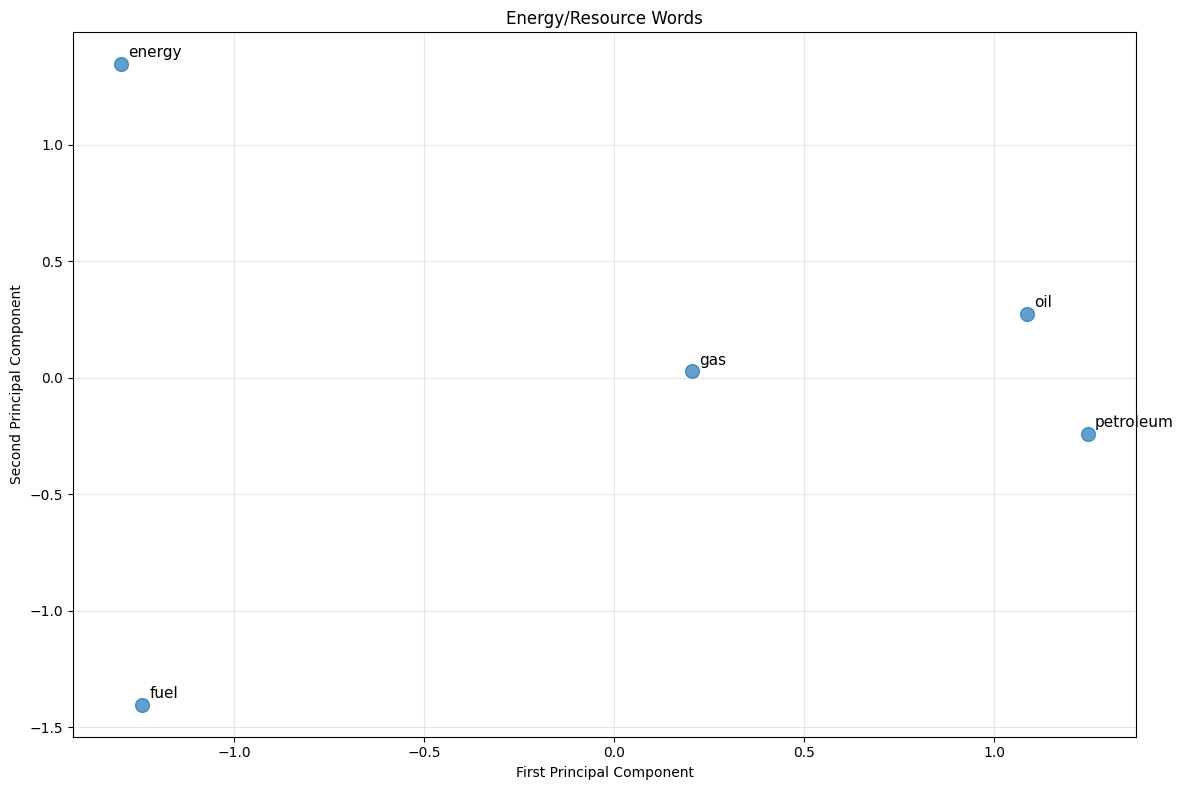

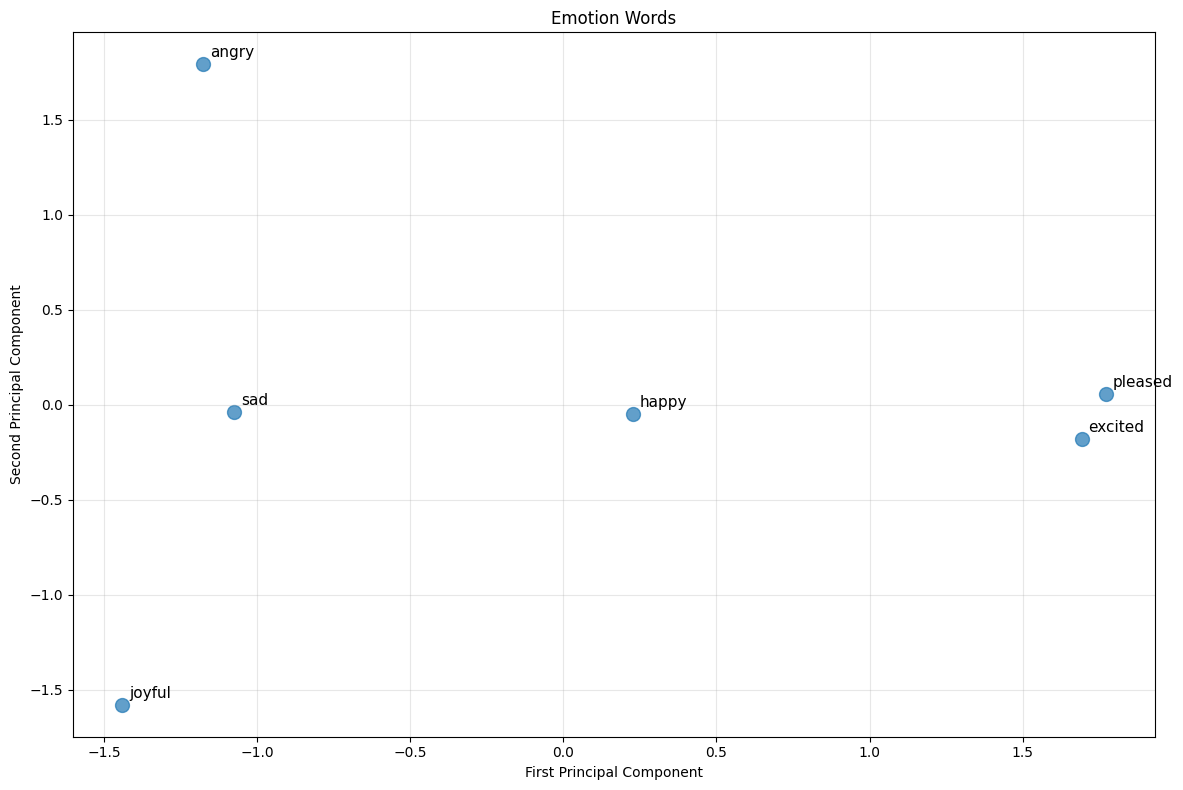

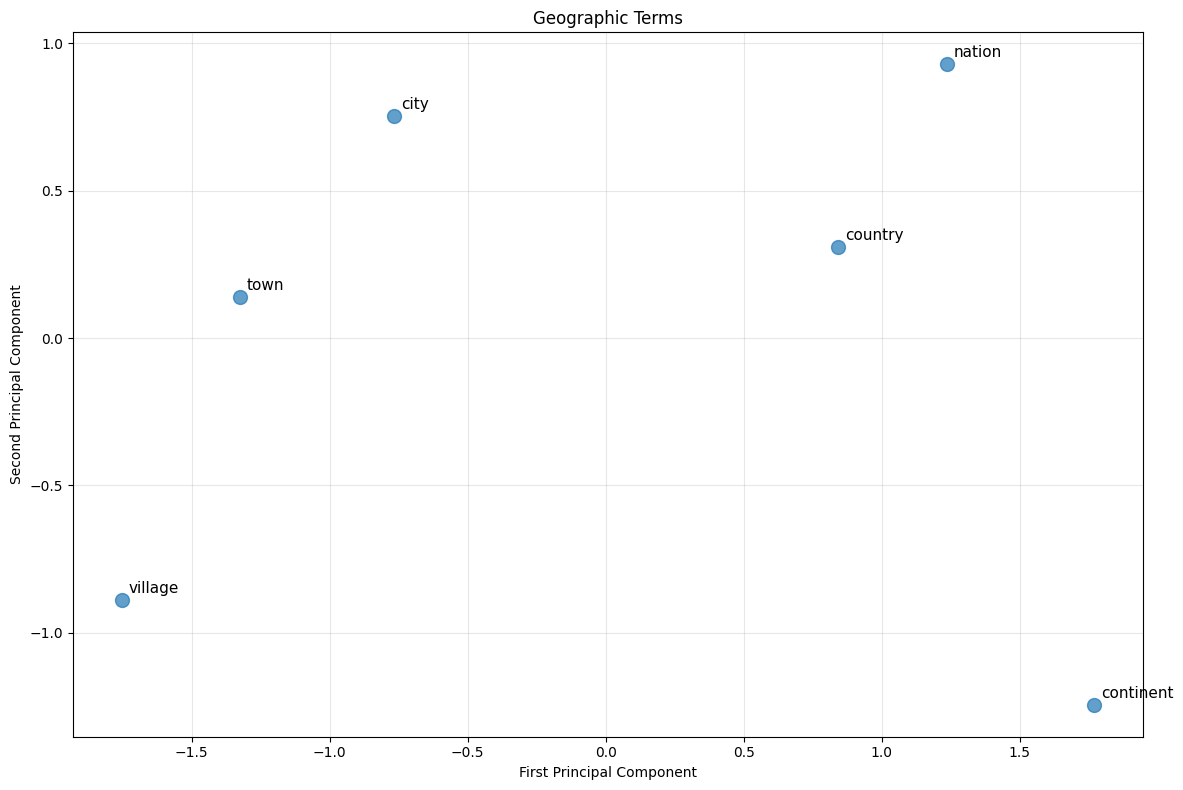

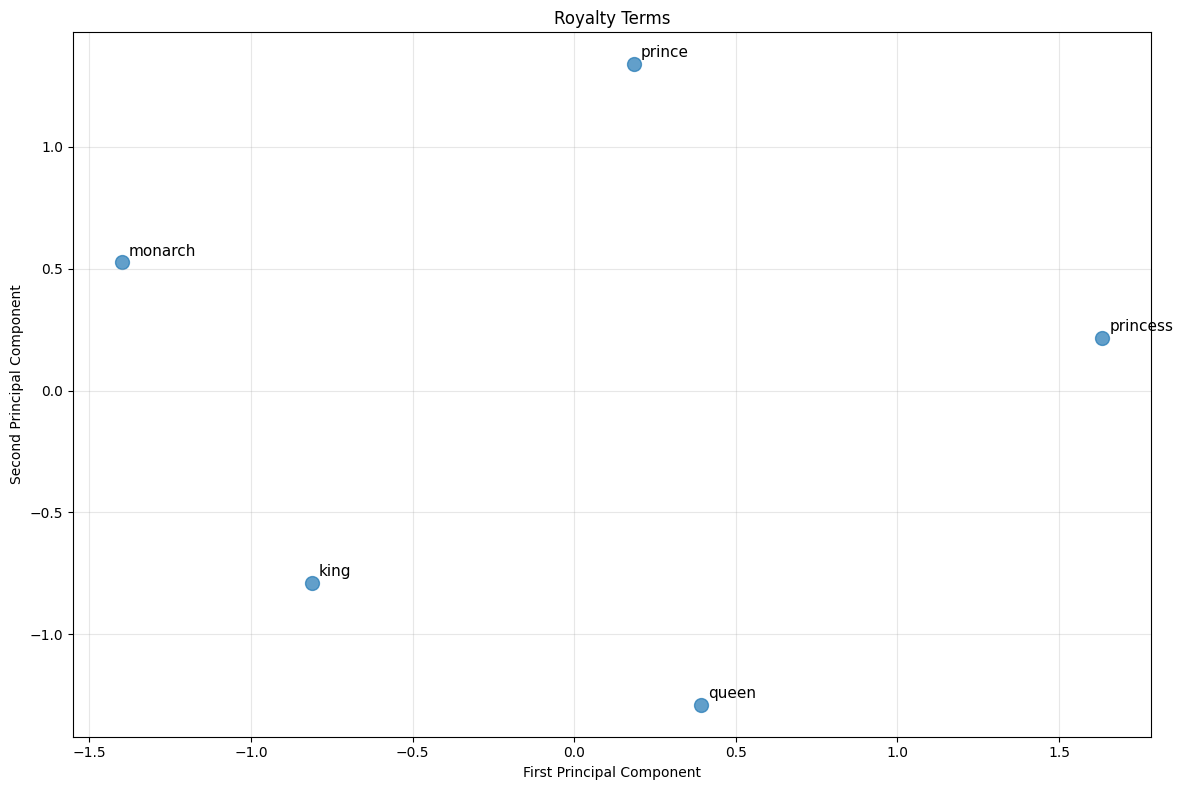

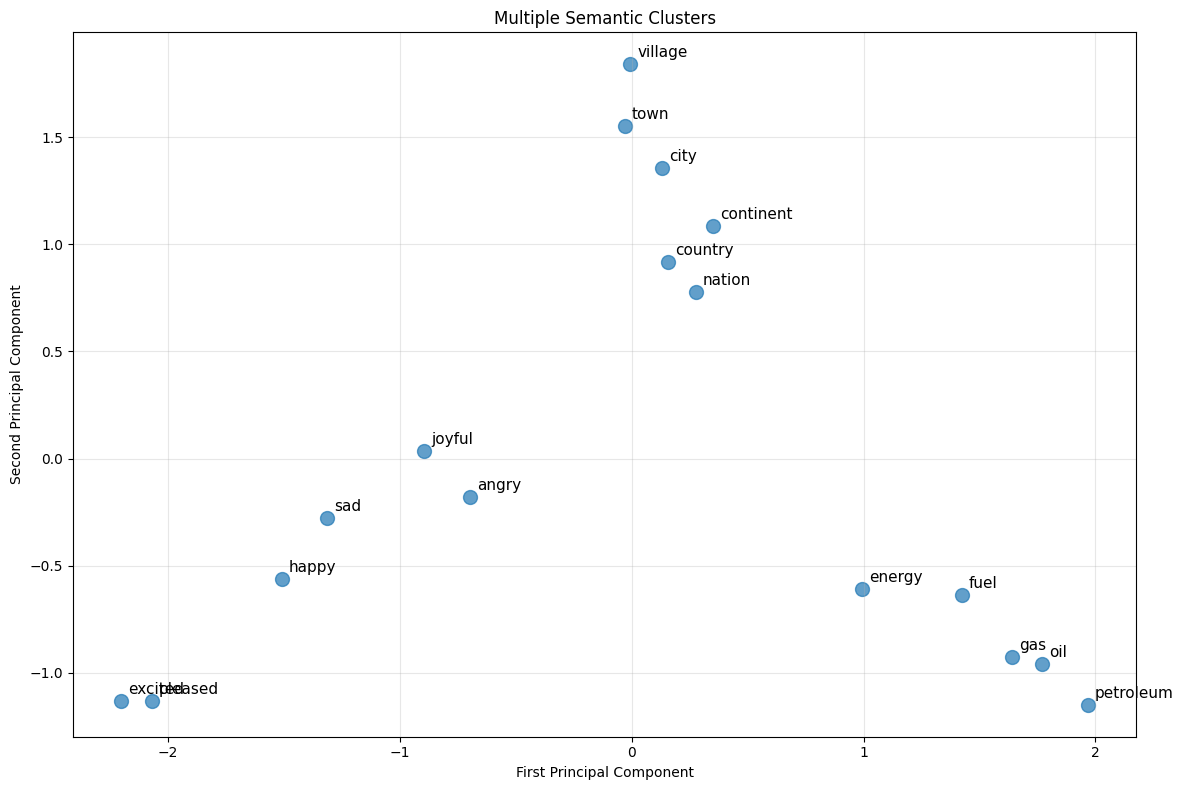

In [25]:
# Cluster 1: Energy/resources
energy_words = ['oil', 'gas', 'petroleum', 'fuel', 'energy']

# Cluster 2: Emotions
emotion_words = ['happy', 'sad', 'joyful', 'excited', 'angry', 'pleased']

# Cluster 3: Places
place_words = ['city', 'town', 'village', 'country', 'continent', 'nation']

# Cluster 4: Royalty
royalty_words = ['king', 'queen', 'prince', 'princess', 'monarch']

# Visualize each cluster
visualize_words(energy_words, word_embeddings, "Energy/Resource Words")
visualize_words(emotion_words, word_embeddings, "Emotion Words")
visualize_words(place_words, word_embeddings, "Geographic Terms")
visualize_words(royalty_words, word_embeddings, "Royalty Terms")

# All together
all_words = energy_words + emotion_words + place_words
visualize_words(all_words, word_embeddings, "Multiple Semantic Clusters")

### Milestone 3.4: Analyze PCA Components

**What to implement**: Understand what PCA components represent

**Questions to answer:**

1. How much variance do the first 2 components capture?
2. How many components needed for 90% variance?
3. Is there a sharp "elbow" in the plot?
4. What does this tell us about the dimensionality of semantic space?

---


PCA COMPONENT ANALYSIS

Component 1:
  Variance explained: 0.2859 (28.59%)
  Cumulative variance: 0.2859 (28.59%)

Component 2:
  Variance explained: 0.2019 (20.19%)
  Cumulative variance: 0.4878 (48.78%)

Component 3:
  Variance explained: 0.1721 (17.21%)
  Cumulative variance: 0.6599 (65.99%)

Component 4:
  Variance explained: 0.0677 (6.77%)
  Cumulative variance: 0.7276 (72.76%)

Component 5:
  Variance explained: 0.0589 (5.89%)
  Cumulative variance: 0.7865 (78.65%)

Component 6:
  Variance explained: 0.0471 (4.71%)
  Cumulative variance: 0.8336 (83.36%)

Component 7:
  Variance explained: 0.0457 (4.57%)
  Cumulative variance: 0.8793 (87.93%)

Component 8:
  Variance explained: 0.0403 (4.03%)
  Cumulative variance: 0.9196 (91.96%)

Component 9:
  Variance explained: 0.0378 (3.78%)
  Cumulative variance: 0.9574 (95.74%)

Component 10:
  Variance explained: 0.0256 (2.56%)
  Cumulative variance: 0.9830 (98.30%)

Total variance explained by 10 components: 0.9830


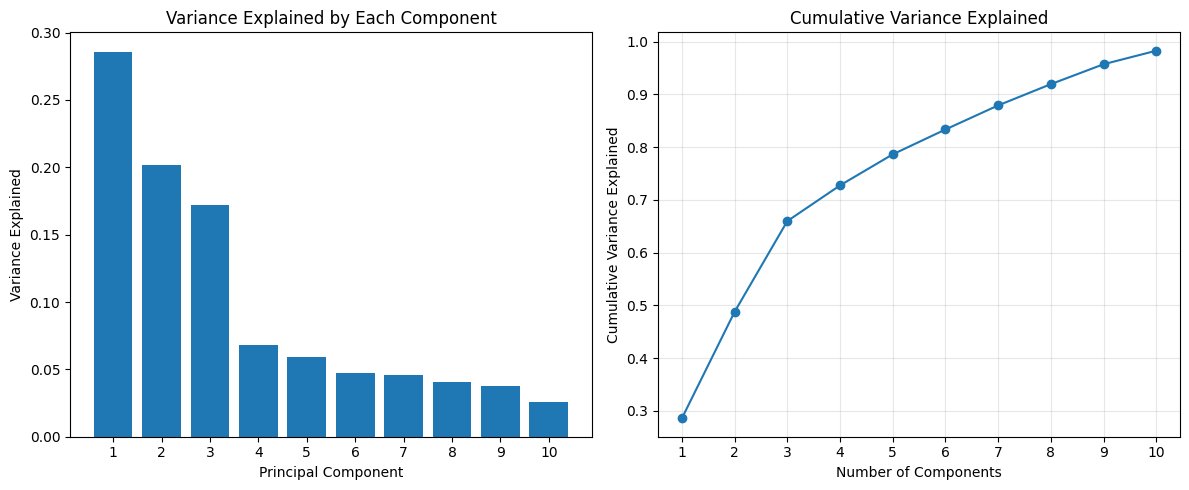

In [26]:
def analyze_pca_components(words, embeddings, n_components=2):
    """
    Analyze what each principal component captures

    Args:
        words: list of words
        embeddings: word embeddings
        n_components: number of components to analyze

    Returns:
        analysis: dictionary with variance info
    """
    # Get vectors
    vectors = np.array([embeddings[word] for word in words])

    # Apply PCA and get full transformation
    X_centered = vectors - np.mean(vectors, axis=0)
    cov_matrix = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Sort
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Calculate explained variance
    total_variance = np.sum(eigenvalues)
    explained_variance_ratio = eigenvalues / total_variance
    cumulative_variance = np.cumsum(explained_variance_ratio)

    # Print analysis
    print("PCA COMPONENT ANALYSIS\n")
    for i in range(min(n_components, 10)):
        print(f"Component {i+1}:")
        print(f"  Variance explained: {explained_variance_ratio[i]:.4f} ({explained_variance_ratio[i]*100:.2f}%)")
        print(f"  Cumulative variance: {cumulative_variance[i]:.4f} ({cumulative_variance[i]*100:.2f}%)")
        print()

    print(f"Total variance explained by {n_components} components: {cumulative_variance[n_components-1]:.4f}")

    # Plot variance
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.bar(range(1, 11), explained_variance_ratio[:10])
    plt.xlabel('Principal Component')
    plt.ylabel('Variance Explained')
    plt.title('Variance Explained by Each Component')
    plt.xticks(range(1, 11))

    plt.subplot(1, 2, 2)
    plt.plot(range(1, 11), cumulative_variance[:10], marker='o')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Variance Explained')
    plt.title('Cumulative Variance Explained')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 11))

    plt.tight_layout()
    plt.show()

    return {
        'eigenvalues': eigenvalues,
        'explained_variance_ratio': explained_variance_ratio,
        'cumulative_variance': cumulative_variance
    }

# Analyze
all_words = ['oil', 'gas', 'petroleum', 'happy', 'sad', 'joyful',
             'city', 'town', 'village', 'king', 'queen', 'prince']
analysis = analyze_pca_components(all_words, word_embeddings, n_components=10)


## Part 4: Creative Exploration

### Challenge 4.1: Find Interesting Analogies

**Your task**: Discover interesting word relationships

**Your creative task**:

1. Find at least 5 novel analogy patterns
2. Test each pattern with 3 examples
3. Report accuracy and interesting failures
4. Explain WHY certain analogies work or don't work

---


In [27]:
def explore_analogies(embeddings):
    """
    Test various analogy patterns
    """
    print("EXPLORING WORD ANALOGIES\n")

    # Pattern 1: Gender relationships
    print("1. GENDER ANALOGIES")
    test_cases = [
        ('king', 'queen', 'man'),
        ('king', 'queen', 'boy'),
        ('uncle', 'aunt', 'brother'),
    ]
    for a, b, c in test_cases:
        result = complete_analogy(a, b, c, embeddings, k=3)
        print(f"{a} : {b} :: {c} : {result[0][0]} (sim={result[0][1]:.3f})")

    # Pattern 2: Comparative adjectives
    print("\n2. COMPARATIVE ADJECTIVES")
    test_cases = [
        ('good', 'better', 'bad'),
        ('big', 'bigger', 'small'),
        ('fast', 'faster', 'slow'),
    ]
    for a, b, c in test_cases:
        result = complete_analogy(a, b, c, embeddings, k=3)
        print(f"{a} : {b} :: {c} : {result[0][0]}")

    # Pattern 3: Country-language
    print("\n3. COUNTRY-LANGUAGE")
    test_cases = [
        ('France', 'french', 'Spain'),
        ('China', 'chinese', 'India'),
        ('Germany', 'german', 'Italy'),
    ]
    for a, b, c in test_cases:
        result = complete_analogy(a, b, c, embeddings, k=3)
        print(f"{a} : {b} :: {c} : {result[0][0]} (sim={result[0][1]:.3f})")

    # Pattern 4: Company-product
    print("\n4. COMPANY-PRODUCT")
    test_cases = [
        ('apple', 'iphone', 'microsoft'),
        ('google', 'search', 'facebook'),
        ('nike', 'shoes', 'rolex'),
    ]
    for a, b, c in test_cases:
        result = complete_analogy(a, b, c, embeddings, k=3)
        print(f"{a} : {b} :: {c} : {result[0][0]} (sim={result[0][1]:.3f})")

explore_analogies(word_embeddings)

EXPLORING WORD ANALOGIES

1. GENDER ANALOGIES
king : queen :: man : woman (sim=0.719)
king : queen :: boy : woman (sim=0.617)
uncle : aunt :: brother : sister (sim=0.823)

2. COMPARATIVE ADJECTIVES
good : better :: bad : faster
big : bigger :: small : faster
fast : faster :: slow : better

3. COUNTRY-LANGUAGE
France : french :: Spain : spanish (sim=0.705)
China : chinese :: India : pakistani (sim=0.610)
Germany : german :: Italy : italian (sim=0.719)

4. COMPANY-PRODUCT
apple : iphone :: microsoft : swedish (sim=0.464)
google : search :: facebook : watch (sim=0.163)
nike : shoes :: rolex : London (sim=0.169)


### Challenge 4.2: Bias Detection

**Important concept**: Embeddings can contain societal biases!

**Critical reflection questions**:

1. Which occupations show strong gender bias?
2. Where does this bias come from?
3. How would you mitigate these biases?
4. Should we "debias" embeddings? What are the tradeoffs?

---


In [31]:
def detect_bias(embeddings):
    """
    Check for gender and occupational biases
    """
    print("BIAS DETECTION\n")

    # Test gender bias in occupations
    occupations = ['doctor', 'nurse', 'engineer', 'teacher',
                   'programmer', 'secretary', 'CEO', 'assistant']

    male_words = ['man', 'he', 'his', 'him', 'male']
    female_words = ['woman', 'she', 'her', 'female']

    # Calculate average male/female vectors
    male_vec = np.mean([embeddings[w] for w in male_words if w in embeddings], axis=0)
    female_vec = np.mean([embeddings[w] for w in female_words if w in embeddings], axis=0)

    print("Occupation gender associations:\n")
    for occupation in occupations:
        if occupation not in embeddings:
            continue

        occ_vec = embeddings[occupation]

        male_sim = cosine_similarity(occ_vec, male_vec)
        female_sim = cosine_similarity(occ_vec, female_vec)

        bias = male_sim - female_sim
        association = "MALE" if bias > 0.05 else "FEMALE" if bias < -0.05 else "NEUTRAL"

        print(f"{occupation:15} Male: {male_sim:.3f}  Female: {female_sim:.3f}  [{association}]")

detect_bias(word_embeddings)

BIAS DETECTION

Occupation gender associations:

doctor          Male: 0.334  Female: 0.325  [NEUTRAL]
nurse           Male: 0.236  Female: 0.455  [FEMALE]
engineer        Male: 0.076  Female: -0.003  [MALE]
teacher         Male: 0.247  Female: 0.325  [FEMALE]
programmer      Male: 0.055  Female: 0.052  [NEUTRAL]
secretary       Male: 0.044  Female: 0.087  [NEUTRAL]
CEO             Male: -0.095  Female: -0.139  [NEUTRAL]
assistant       Male: 0.152  Female: 0.155  [NEUTRAL]


### Challenge 4.3: Domain-Specific Embeddings

**Your task**: Compare different embedding types

**If you downloaded multiple embeddings**:

---


In [30]:

def compare_embeddings(word, embedding_dict):
    """
    Compare how different embeddings represent the same word

    Args:
        word: word to compare
        embedding_dict: dict of {name: embeddings}
    """
    print(f"=== COMPARING EMBEDDINGS FOR '{word}' ===\n")

    for name, embeddings in embedding_dict.items():
        if word not in embeddings:
            print(f"{name}: Word not found")
            continue

        vec = embeddings[word]

        # Find nearest neighbors
        similarities = []
        for other_word, other_vec in embeddings.items():
            if other_word == word:
                continue
            sim = cosine_similarity(vec, other_vec)
            similarities.append((other_word, sim))

        similarities.sort(key=lambda x: x[1], reverse=True)

        print(f"{name} - Top 5 similar words:")
        for w, s in similarities[:5]:
            print(f"  {w}: {s:.3f}")
        print()

# # Example usage
# embeddings_comparison = {
#     'Word2Vec': word2vec_embeddings,
#     'GloVe': glove_embeddings,
#     'FastText': fasttext_embeddings
# }

# compare_embeddings('doctor', embeddings_comparison)
# compare_embeddings('happy', embeddings_comparison)


## Submission Checklist

### Code Implementation

- [ ] `cosine_similarity(vec_a, vec_b)` - Similarity metric
- [ ] `euclidean_distance(vec_a, vec_b)` - Distance metric
- [ ] `complete_analogy(a, b, c, embeddings, k)` - Analogy solver
- [ ] `get_country(city1, country1, city2, embeddings)` - Country prediction
- [ ] `get_analogy_accuracy(data, embeddings)` - Accuracy calculation
- [ ] `compute_pca(X, n_components)` - PCA implementation
- [ ] `visualize_words(words, embeddings)` - Visualization function
- [ ] `analyze_pca_components(words, embeddings)` - Component analysis

## Reflection Questions

Answer the provided reflection questions about metrics, PCA, analogies, limitations, and applications.

## Success Criteria

Key mastery points: implement metrics, analogies, PCA visualizations, country-capital accuracy > 85%, and explain findings.

## Key Takeaways

- Cosine similarity vs Euclidean distance
- Vector arithmetic encodes relationships
- PCA projects high-dimensional geometry into interpretable 2D plots

## Week Progression Summary

Summary of Weeks 1→3 and how approaches evolve from features to geometry.

## Common Issues

Troubleshooting tips for cosine outputs, PCA centering, analogy errors, performance and visualization.

## Pro Tips

Start small, vectorize computations, visualize often, and explore unexpected analogies.

## What's Next: Week 4 Preview

Preview of Machine Translation and Locality Sensitive Hashing.

**Congratulations on completing Week 3!** 🎉

You now know how to work with word embeddings, similarity metrics, analogies and PCA visualizations.